In [12]:

import sys, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1,Normalize
from model.model import myInformer
from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

# from model.epx import drawTrain
from tqdm import tqdm
from pickle import load

In [2]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 1000
d_ff= 2048
ENC_LAYER=2
DEC_LAYER=1
PRED_LEN =24
FEATURES= 7
TIME_FEATURES = 4
EPOCHS = 3
settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff,
            'e_layer':ENC_LAYER, 'd_layer':DEC_LAYER, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES }
# print(settings)
# Creation du model Exp
myExpFct = Exp(settings)
myExpFct.build()
myExpFct._buildModel(0.000_01)
model = myExpFct.train(EPOCHS)
# # Formatage des données
# dX, dy = list(myExpFct.dataset)[59]
# X = dX[:,:,0:7]
# declen = SEQ_LEN//2
# X_dec = X[:,0:declen,:]
# Xdate = dX[:,:,7:]
# Xdate_dec = Xdate[:,0:declen,:]
# y = dy[:]
# print(dy.shape)
# X_dec_padd = tf.zeros(shape=(BATCH_SIZE,PRED_LEN,X.shape[-1]))
# X_date_dec_padd = tf.zeros(shape=(BATCH_SIZE,PRED_LEN,Xdate.shape[-1]))
# X_dec = tf.concat([X_dec,X_dec_padd],1)
# Xdate_dec = tf.concat([Xdate_dec,X_date_dec_padd],1)

# pred = myExpFct.pred(X,X_dec,Xdate, Xdate_dec, training=False)
# # pred = myExpFct._pred()

# B,L,F = pred.shape
# pred = myExpFct.scaler.inverse_transform(tf.reshape(pred,shape=(B*L,F)))
# pred = tf.cast(tf.reshape(pred, shape=(B,L,F)), tf.float32)
# x_padd = tf.zeros(shape=(BATCH_SIZE,24,7))
# pred = tf.concat([x_padd,pred],1)

# x_ = myExpFct.x_enc

# B,L,F = x_.shape
# x_ = tf.reshape(x_, shape=(B*L,F))
# x_ = myExpFct.scaler.inverse_transform(x_)
# x_ = tf.reshape(x_, shape=(B,L,F))

# v_min = tf.reduce_min(x_)
# v_max = tf.reduce_max(x_)

# fig = plt.figure(figsize=(18,2))
# plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,6].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'r--', label="Predicted");
# plt.plot(range(x_[0,0:SEQ_LEN-PRED_LEN,6].shape[0]),x_[0,0:SEQ_LEN-PRED_LEN,6], label="Training");
# plt.plot(range(SEQ_LEN-PRED_LEN, SEQ_LEN),x_[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'g:', label="Réel ?");
# plt.legend();

# fig = plt.figure(figsize=(18,2))
# # ax = fig.subplots(221)
# for i in range(0,BATCH_SIZE,32):
#     sns.heatmap(x_[i,:,:], vmin=v_min, vmax=v_max, cmap=sns.color_palette("hls", 256)).set_title('encoder x');# for i in range(0,BATCH_SIZE,8):

# df_raw = myExpFct.dataFct.df_Data
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(x=df_raw['date'][0:1000],y=df_raw['OT'][0:1000]).set_title('Torch EMbedding');
# # plt.plot( data=df_raw[['date','OT']][0:1000], label='Torch EMbedding');


Epoch: 0 -> loss=7.27/0.00 -> Accuracy=28.04%/0.00% - [31.61s]
Epoch: 1 -> loss=4.23/0.00 -> Accuracy=36.09%/0.00% - [26.77s]
Epoch: 2 -> loss=3.57/0.00 -> Accuracy=40.29%/0.00% - [28.23s]
Total time taken: 86.6s


ValueError: x and y must have same first dimension, but have shapes (3,) and (0,)

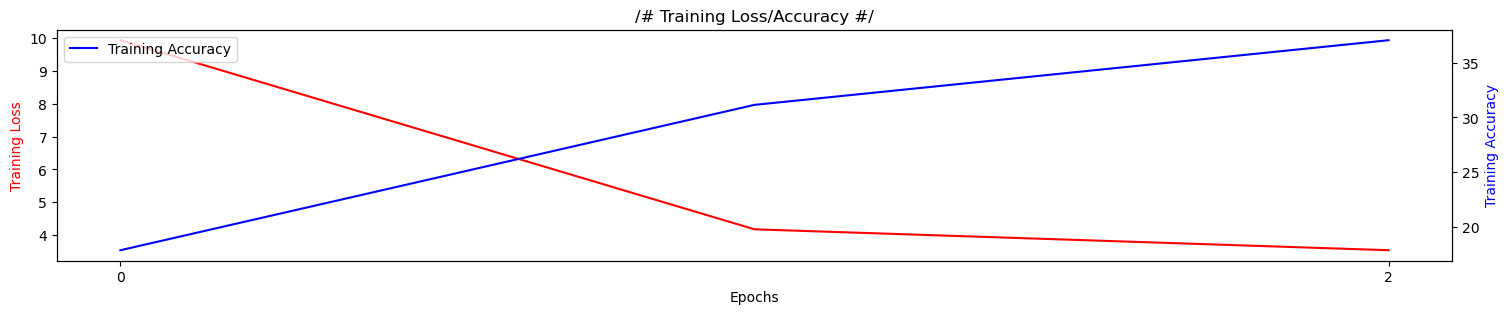

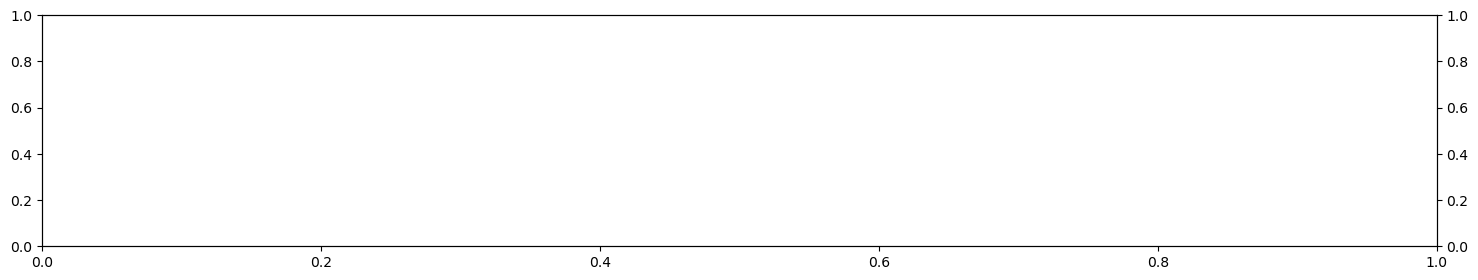

In [7]:
# Visualisation des Courbes d'appretissage

# Load the training and validation loss dictionaries
train_loss = load(open('train_loss.pkl', 'rb'))
train_accuracy = load(open('train_accuracy.pkl', 'rb'))
val_loss = load(open('val_loss.pkl', 'rb'))
val_accuracy = load(open('val_accuracy.pkl', 'rb'))
 
# Retrieve each dictionary's values
train_values = train_loss.values()
train_acc_values = train_accuracy.values()
val_values = val_loss.values()
val_acc_values = val_accuracy.values()
 
# Generate a sequence of integers to represent the epoch numbers
g_epochs = range(0, 3)

fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, train_values, label='Training Loss', color='red')
# ax2.plot(g_epochs, train_values, label='Training Loss', color='blue')
ax2.plot(g_epochs, train_acc_values, label='Training Accuracy', color='blue')
 
# Add in a title and axes labels
plt.title('/# Training Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss',color='red')
ax2.set_ylabel('Training Accuracy',color='blue')
# Set the tick locations
plt.xticks(np.arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()
#----------------------------
fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, val_values, label='Validation Loss', color='red')
ax2.plot(g_epochs, val_acc_values, label='Validation Accuracy', color='blue')
# Add in a title and axes labels
plt.title('/# Validation Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Validation Loss',color='red')
ax2.set_ylabel('Validation Accuracy',color='blue')
# Set the tick locations
plt.xticks(np.arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()

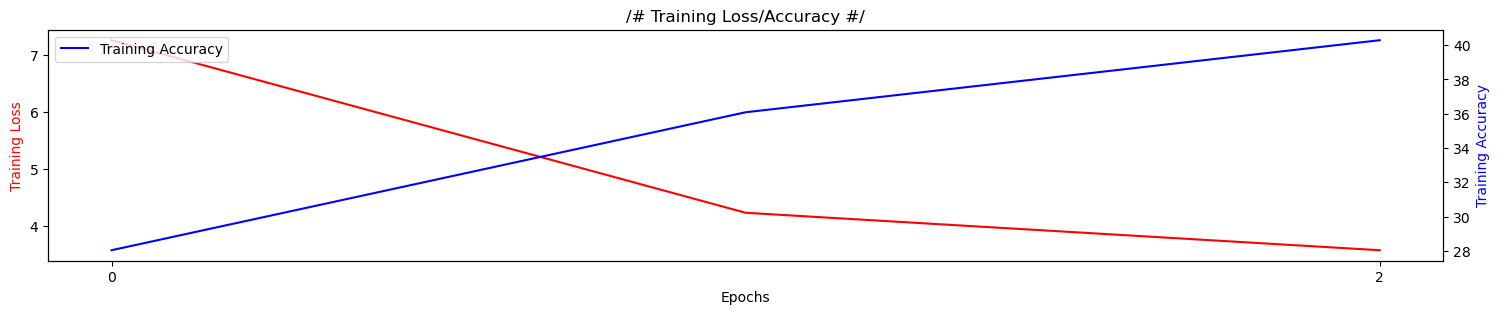

In [3]:
myExpFct.drawTrain()


(32, 96, 11)
X (96, 7)
Xdate (96, 4)
(1, 48, 4)
(1, 24, 4)
(1, 96, 7)
(1, 96, 4)
(1, 72, 7)
(1, 72, 4)
tf.Tensor(
[0.7327686  0.519023   0.5079441  0.5115639  0.48444262 0.4712998
 0.48758498 0.5366044  0.58748406 0.6040505  0.563579   0.47236928
 0.43016776 0.4445158  0.53375036 0.6389962  0.68227684 0.7059181
 0.59938025 0.5318806  0.5244054  0.5952759  0.6912351  0.74534744], shape=(24,), dtype=float32)
(1, 24, 7)


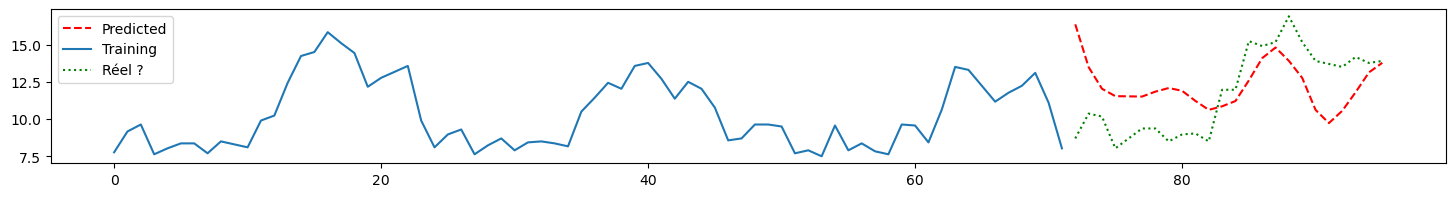

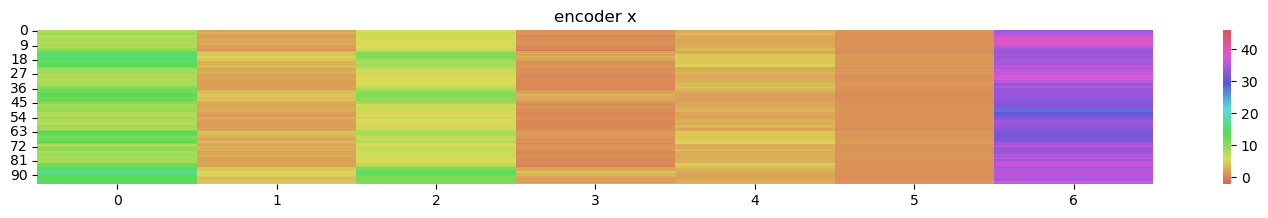

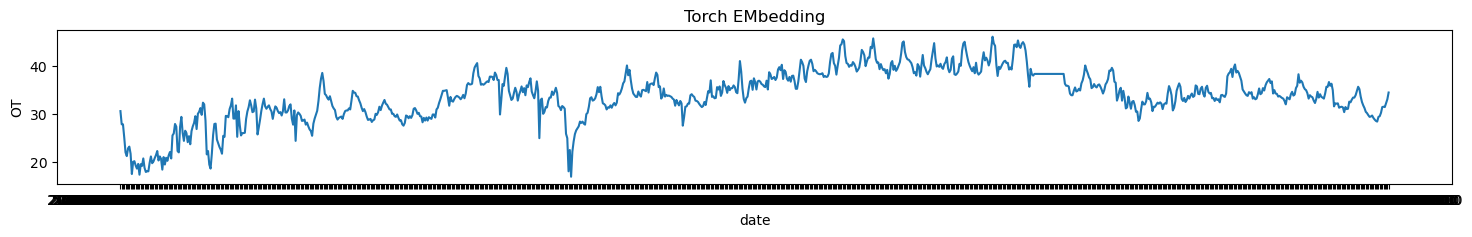

In [5]:
# EXP
# model.batch_size=1
# Formatage des données
dX, dy = list(myExpFct.dataset)[1]
print(dX.shape)
X = dX[0,:,0:7]
print('X',X.shape)
declen = SEQ_LEN//2
X_dec = X[:declen,:]
Xdate = dX[0,:,7:]
print('Xdate',Xdate.shape)
Xdate_dec = dX[0,0:declen,7:]
X = tf.reshape(X, shape=(1,SEQ_LEN,7))
Xdate = tf.reshape(Xdate,shape=(1,SEQ_LEN,4))
X_dec = tf.reshape(X_dec, shape=(1,declen,7))
Xdate_dec = tf.reshape(Xdate_dec, shape=(1,declen,4))
X_dec_padd = tf.zeros(shape=(1,PRED_LEN,X.shape[-1]))
X_date_dec_padd = tf.zeros(shape=(1,PRED_LEN,Xdate.shape[-1]))
X_dec = tf.concat([X_dec,X_dec_padd],1)
print(Xdate_dec.shape)
print(X_date_dec_padd.shape)
Xdate_dec = tf.concat([Xdate_dec,X_date_dec_padd],1)

print(X.shape)
print(Xdate.shape)
print(X_dec.shape)
print(Xdate_dec.shape)
# pred = myExpFct.pred(X,X_dec, Xdate, Xdate_dec, training=False)[0]
pred = model(X,Xdate,X_dec, Xdate_dec, training=False)[0]
pred = tf.reshape(pred,shape=(1,PRED_LEN,7))
print(pred[0,:,6])
print(pred.shape)
B,L,F = pred.shape
pred = myExpFct.scaler.inverse_transform(tf.reshape(pred,shape=(B*L,F)))
pred = tf.cast(tf.reshape(pred, shape=(B,L,F)), tf.float32)
x_padd = tf.zeros(shape=(1,72,7))
pred = tf.concat([x_padd,pred],1)

x_ = myExpFct.x_enc

B,L,F = x_.shape
x_ = tf.reshape(x_, shape=(B*L,F))
x_ = myExpFct.scaler.inverse_transform(x_)
x_ = tf.reshape(x_, shape=(B,L,F))

v_min = tf.reduce_min(x_)
v_max = tf.reduce_max(x_)

feat=0

fig = plt.figure(figsize=(18,2))
plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,feat].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,feat], 'r--', label="Predicted");
plt.plot(range(x_[0,0:SEQ_LEN-PRED_LEN,feat].shape[0]),x_[0,0:SEQ_LEN-PRED_LEN,feat], label="Training");
plt.plot(range(SEQ_LEN-PRED_LEN, SEQ_LEN),x_[0,SEQ_LEN-PRED_LEN:SEQ_LEN,feat], 'g:', label="Réel ?");
plt.legend();

fig = plt.figure(figsize=(18,2))
# ax = fig.subplots(221)
for i in range(0,BATCH_SIZE,32):
    sns.heatmap(x_[i,:,:], vmin=v_min, vmax=v_max, cmap=sns.color_palette("hls", 256)).set_title('encoder x');# for i in range(0,BATCH_SIZE,8):

df_raw = myExpFct.dataFct.df_Data
fig = plt.figure(figsize=(18,2))
sns.lineplot(x=df_raw['date'][0:1000],y=df_raw['OT'][0:1000]).set_title('Torch EMbedding');
# plt.plot( data=df_raw[['date','OT']][0:1000], label='Torch EMbedding');


In [ ]:
print(myExpFct.dataFct.data[0:3,:])
print(myExpFct.dataFct.df_Data.iloc[0:5])
print(myExpFct.dataFct.df_Data.shape)

In [ ]:
print(tf.reduce_max(myExpFct.X).numpy())
print(myExpFct.dataFct.dataN.shape)
print(tf.reduce_min(myExpFct.dataFct.dataN).numpy())
print(tf.reduce_max(myExpFct.dataFct.dataN).numpy())
print(tf.reduce_mean(myExpFct.dataFct.dataN).numpy())
print(myExpFct.dataFct.df_Data.describe())
print(myExpFct.dataFct.scalerData)
print((myExpFct.X.shape))
print(tf.reduce_max(myExpFct.X[:,:,6]))

In [ ]:
print(11*17420)

In [6]:
def getData(data,init,seq_len=96,pred_len=24):
    dec_len = seq_len//2
    dec_all = dec_len + pred_len
    Xe = data[init:init+seq_len,0:7]
    Xed = data[init:init+seq_len,7:]
    padd = tf.zeros((pred_len,11))
    Xd = tf.concat([data[init:init+dec_len,:7],padd[:,:7]],axis=0)
    Xdd = tf.concat([data[init:init+dec_len,7:],padd[:,7:]],axis=0)
    Xe = tf.reshape(Xe, shape=(1,seq_len,7))
    Xed = tf.reshape(Xed, shape=(1,96,4))
    Xd = tf.reshape(Xd, shape=(1,dec_all,7))
    Xdd = tf.reshape(Xdd, shape=(1,dec_all,4))
    Xr = data[init:init+dec_all,:7]
    Xr = tf.reshape(Xr, shape=(dec_all,7))
    return Xe,Xed,Xd,Xdd,Xr


{'batch_size': 32, 'seq_len': 96, 'global_size': 16000, 'd_model': 512, 'd_ff': 2048, 'e_layer': 2, 'd_layer': 1, 'rate': 0.05, 'factor': 5, 'heads': 8, 'pred_len': 24, 'features': 7, 'timeFeatures': 4}


100%|██████████| 10/10 [00:01<00:00,  6.43it/s]


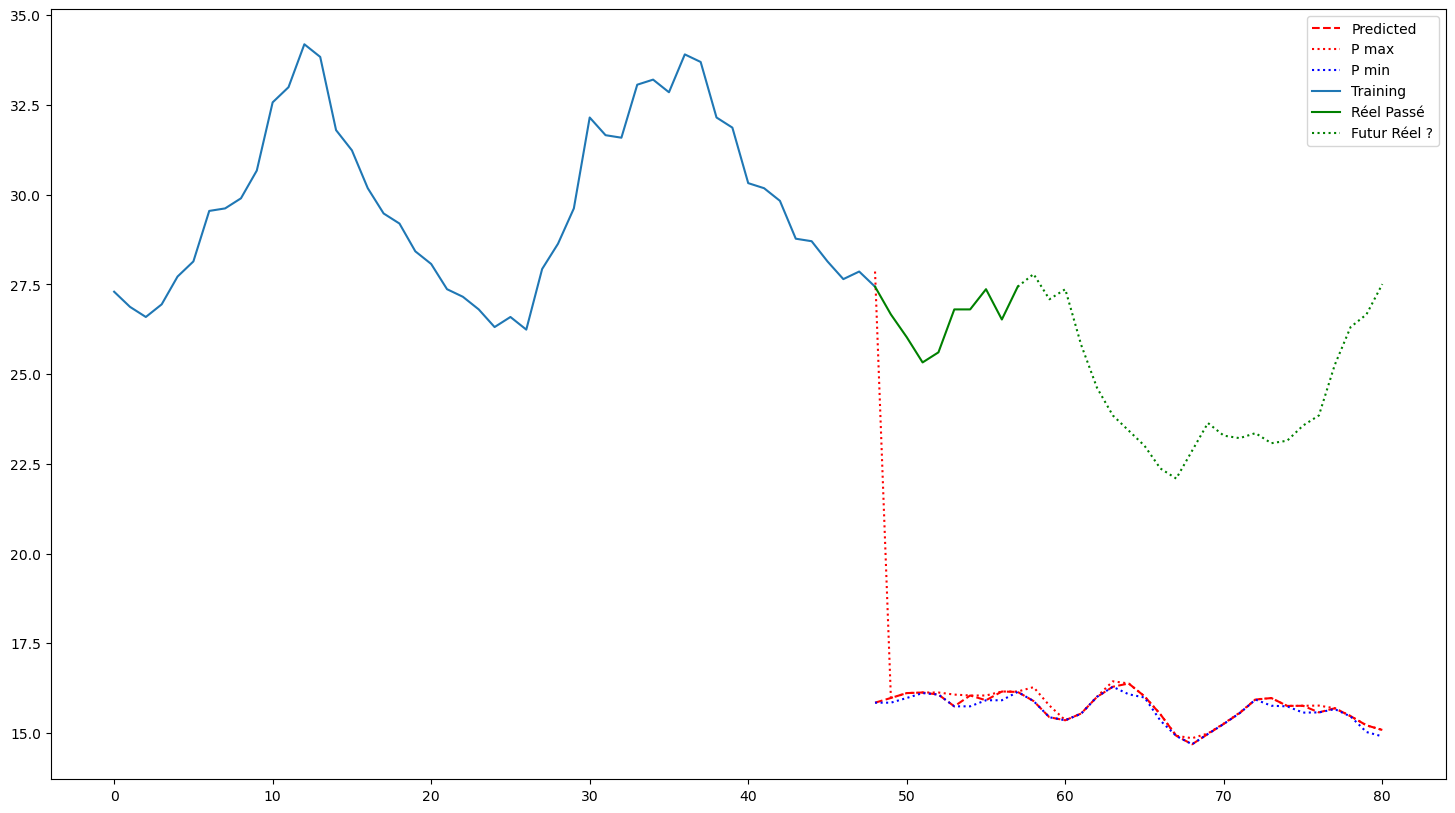

In [29]:
# EXP
# d_model = 512
# HEADS = 8
# RATE = 0.05
# SEQ_LEN = 96
# FACTOR = 5
# BATCH_SIZE = 32
# GLOBAL_SIZE = 6400
# d_ff= 2048
# N=2
# PRED_LEN =24
# FEATURES= 7
# TIME_FEATURES = 4
# EPOCHS = 10
# settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff,
#             'e_layer':N, 'd_layer':1, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES }
# Creation du model Exp
settings = load(open('./settings/settings.sav','rb'))
print(settings)
myExpFct = Exp(settings)
myExpFct.build()
# Chargement du model
# new_modelExp = Exp(settings=settings)
new_model = myExpFct.modelFct
new_model.load_weights('weights/wghts20.ckpt')
myExpFct.dataFct.scalerData = load(open('./scaler/scaler.sav', 'rb'))
myExpFct.scaler = load(open('./scaler/scaler.sav', 'rb'))

# Prédictions ...
init = 1300
feat=6
forecast = 10

data = myExpFct.dataFct.data
_,_,_,_,Xi = getData(data,init,96,24)
Xi = Xi[:-1,:]
Pi = tf.cast(Xi,tf.float32)
Pimin = Pi
Pimax = Pi
Pia = Pi
# for i in (range (forecast)):
for i in tqdm(range (init, init+forecast)):
    Xe,Xed,Xd,Xdd,Xr = getData(data,i,96,24)
    pred = new_model(Xe,Xed,Xd, Xdd, training=False)[0]
    # predOne = tf.cast(tf.reshape(pred,shape=(PRED_LEN,7)),tf.float32)[None,0,:]
    # predOne = tf.reduce_mean(pred,axis=1)
    predAll = tf.cast(tf.reshape(pred,shape=(PRED_LEN,7)),tf.float32) 
    # L,F = Pi.shape
    Li,F = Pia.shape
    # compute min/max
    b = tf.concat([pred,Pia[None,-24:,:]],axis=0)
    bmax= tf.reduce_max(b,axis=0)
    bmin= tf.reduce_min(b,axis=0)
    # print(pred[0,0],bmax[0],b[0,0],b[1,0],bmin[0])
    Pimax = tf.concat([Pimax[:Li-23,:],bmax],axis=0)
    Pimin = tf.concat([Pimin[:Li-23,:],bmin],axis=0)
    # print(L, Pi.shape, predOne.shape, predAll.shape,Pia.shape)
    Xi = tf.concat([Xi,Xr[None,-1,:]],axis=0)
    # Pi = tf.concat([Pi,predOne],axis=0)
    Pia = tf.concat([Pia[:Li-23,:],predAll],axis=0)

# L,F = Pi.shape
Li,F = Pia.shape
# Pi = myExpFct.scaler.inverse_transform(tf.reshape(Pi,shape=(L,F)))
Pia = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pia,shape=(Li,F)))
Pimax = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimax,shape=(Li,F)))
Pimin = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimin,shape=(Li,F)))
# x_padd = tf.zeros(shape=(48,7))
# pred = tf.concat([x_padd,pred],axis=0)
# print(pred.shape)

x_ = myExpFct.dataFct.scalerData.inverse_transform(Xi)
df_raw = myExpFct.dataFct.df_Data

v_min = math.ceil( tf.reduce_min(x_[:,feat]) / 10.) * 10. - 10.
v_max = math.floor( (math.ceil( tf.reduce_max(x_[:,feat])/10.) * 10) )

deb = 48 +1 + forecast
fin = 71 + forecast

fig = plt.figure(figsize=(18,10))
# plt.ylim(v_min, v_max )
# plt.plot(range(48, fin),Pi[48:fin,feat], 'r--', label="Predicted");
plt.plot(range(48, fin),Pia[48:fin,feat], 'r--', label="Predicted");
plt.plot(range(48, fin),Pimax[48:fin,feat], 'r:', label="P max");
plt.plot(range(48, fin),Pimin[48:fin,feat], 'b:', label="P min");
plt.plot(range(0,49),x_[0:49,feat], label="Training");
plt.plot(range(48,fin-23),x_[48:fin-23,feat], 'g', label="Réel Passé");
plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();



In [88]:
def padding_mask(input):
    # Create mask which marks the zero padding values in the input by a 1.0
    mask = math.equal(input, 0)
    print(mask)
    mask = tf.cast(mask, tf.float32)
    print(mask)
    # The shape of the mask should be broadcastable to the shape
    # of the attention weights that it will be masking later on
    return mask[:, newaxis, newaxis, :]

def lookahead_mask(shape):
    # Mask out future entries by marking them with a 1.0
    mask = 1 - tf.linalg.band_part(tf.ones((shape, shape)), -1, 0)
    return mask*(-1e9)

def input_mask(a,b):
    # Mask out future entries by marking them with a 1.0
    mask = 1 - tf.linalg.band_part(tf.ones((a, b)), -1, 0)
    return mask*(-1e9)
# fig = plt.figure(figsize=(5,2))
# sns.heatmap(lookahead_mask(10))

In [ ]:
XXXt = Xr
print(Xr.shape)
XXXt= tf.concat([XXXt[:48,:],XXXt[48:,:] * 0.0], axis=0)
# print(XXXt)
maskX = tf.cast(tf.math.equal(XXXt, 0.),tf.float32)
maskP = tf.cast(tf.math.not_equal(XXXt, 0.),tf.float32)
print(maskX,maskP)


In [ ]:
t = input_mask(96,7)
print(t)